# Clasificando gestos musculares

## Cuatro gestos de la mano:
1. Piedra - 0

2. Tijera - 1

3. Papel - 2

4. Ok - 3


Nuestro objetivo es crear un clasificador que distinga correctamente entre estos 4 gestos, gestionando problemas como robustez al ruido y capacidad de generalización con múltiples sujetos.

In [81]:
# librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)
import math

## Cargando datos

In [76]:
# 4 csvs (1 por clase) -> unirlos en 1

df_0 = pd.read_csv("data/0.csv", header=None)
df_1 = pd.read_csv("data/1.csv", header=None)
df_2 = pd.read_csv("data/2.csv", header=None)
df_3 = pd.read_csv("data/3.csv", header=None)


# última col -> label (65)
df = pd.concat([df_0, df_1, df_2, df_3], ignore_index=True)

### Balance de clases

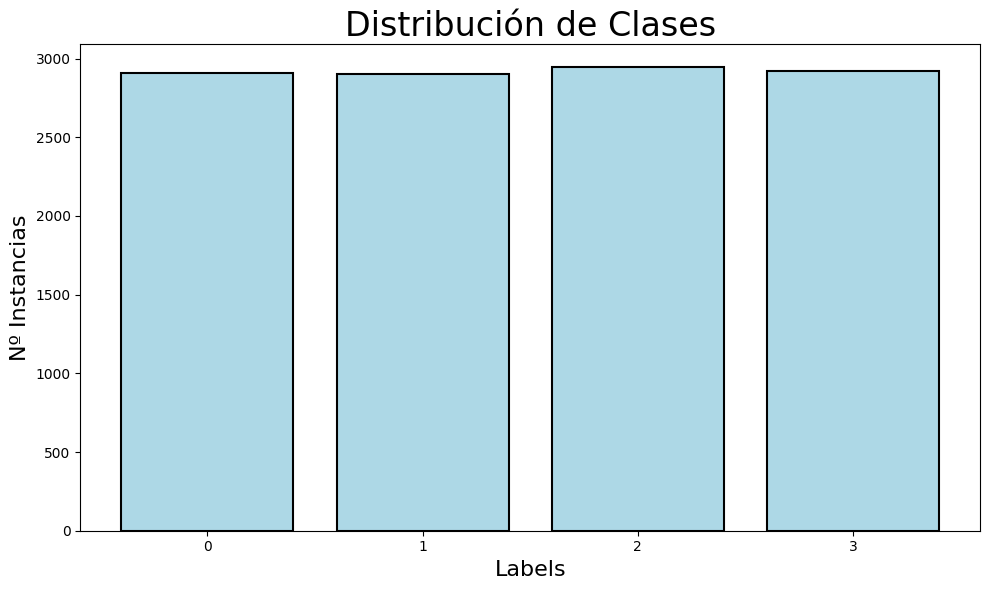

In [18]:
plt.figure(figsize=(10, 6))

instancias_por_clase = {"0" : len(df_0), # label : n_instancias
                        "1" : len(df_1),
                        "2" : len(df_2),
                        "3" : len(df_3)}

# bar plot
labels = instancias_por_clase.keys()
n_instancias = instancias_por_clase.values()
plt.bar(labels, n_instancias, edgecolor="black", lw=1.5, color="lightblue")
plt.title("Distribución de Clases", fontsize=24)
plt.xlabel("Labels", fontsize=16)
plt.ylabel("Nº Instancias", fontsize=16)
plt.tight_layout()
plt.show()

Separamos datos em X e y

In [77]:
# separar características y labels
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Visualización

In [ ]:


reducer = umap.UMAP(
    n_components=3,
    n_neighbors=30,
    random_state=42,
    )
X_umap = reducer.fit_transform(X_scaled)

/home/jordi/Escritorio/uni/3/c2/Aprendizaje Avanzado/proyecto/entorno_proyecto/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


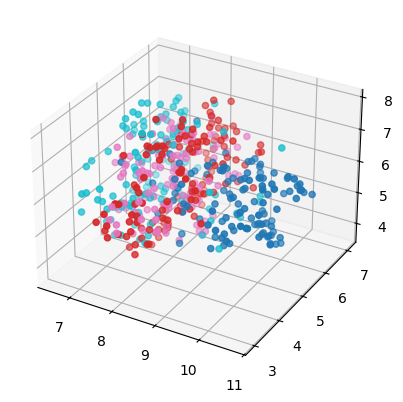

In [12]:
mask = np.random.choice(np.arange(len(X_umap)), size=500, replace=False)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(X_umap[mask, 0], X_umap[mask, 1], X_umap[mask, 2], c=y[mask], cmap="tab10")
plt.show()

### Train / Test Splits

In [95]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

### Clasificando con AdaBoost

In [100]:
for depth in [1, 2, 3, 5]:
    for n_estimator in [25, 50, 75]:
        print("*"*10 + f" Entrenando con depth: {depth} y n_estimators: {n_estimator} " + "*"*10)
        ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=depth), n_estimators=n_estimator, random_state=42)
        ada.fit(X_train, y_train)
        y_pred = ada.predict(X_test)

        print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}", end='|')
        print(f" Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f} ", end='|')
        print(f" Recall (macro): {recall_score(y_test, y_pred, average='macro'):.4f} ", end='|')
        print(f" F1-Score (macro): {f1_score(y_test, y_pred, average='macro'):.4f}\n")




********** Entrenando con depth: 1 y n_estimators: 25 **********
Accuracy: 0.6271| Precision (macro): 0.6880 | Recall (macro): 0.6282 | F1-Score (macro): 0.6197

********** Entrenando con depth: 1 y n_estimators: 50 **********
Accuracy: 0.7442| Precision (macro): 0.7697 | Recall (macro): 0.7443 | F1-Score (macro): 0.7491

********** Entrenando con depth: 1 y n_estimators: 75 **********
Accuracy: 0.8068| Precision (macro): 0.8211 | Recall (macro): 0.8067 | F1-Score (macro): 0.8084

********** Entrenando con depth: 2 y n_estimators: 25 **********
Accuracy: 0.8425| Precision (macro): 0.8478 | Recall (macro): 0.8425 | F1-Score (macro): 0.8439

********** Entrenando con depth: 2 y n_estimators: 50 **********
Accuracy: 0.8610| Precision (macro): 0.8643 | Recall (macro): 0.8610 | F1-Score (macro): 0.8621

********** Entrenando con depth: 2 y n_estimators: 75 **********
Accuracy: 0.8784| Precision (macro): 0.8831 | Recall (macro): 0.8785 | F1-Score (macro): 0.8797

********** Entrenando con de